# Tufa Labs ARC3 submission

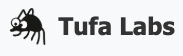

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import os; os.environ["WARPACK_FORCE_OFFLINE_BENCH"] = "1"  # EVAL BUILD: run the offline bench at build time (see build_eval_notebook.py)
os.environ["A17_CANARY_SEED"] = "2"  # A17 72B-VL canary (scope v2 sec3 rho_action denominator; sec5 full 7920s window)
print("A17-CANARY seed=2 mode=throughput-canary-v6-dataset-weights games=ft09-0d8bbf25,sb26-7fbdac44,lp85-305b61c3,vc33-5430563c composition=W0+fencedrec; weights=DATASET canivel/qwen25-vl-72b-awq (model_sources route DEAD, silently dropped at push 07-25/07-26); window=7920s FULL BENCH (07-26 v4 prereg G1-G4 + rho_action denominator 480/Sigma N_72B), output MEASUREMENT ONLY (a17_error_model.md: no NO-GO reading at k=1)")
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

# --- Warpack fast-submit gate (fork-band adoption R1a) -----------------------
# Heavy setup (wheel install, source import, vLLM boot, benchmark run) only
# happens in a real competition rerun, or when explicitly forced for a
# build-time offline eval (WARPACK_FORCE_OFFLINE_BENCH=1). An interactive
# Save Version therefore finishes in seconds with a dummy submission.parquet
# (see the run cell) -> daily resubmission costs ~no GPU quota; the official
# score is the max over stochastic reruns.
FORCE_OFFLINE_BENCH = os.environ.get("WARPACK_FORCE_OFFLINE_BENCH", "").strip().lower() in {"1", "true"}
RUN_HEAVY = TRUE_SUBMISSION or FORCE_OFFLINE_BENCH
print(f"taaf.kaggle: RUN_HEAVY={RUN_HEAVY} (fast-submit gate {'off' if RUN_HEAVY else 'ON'})")


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Warpack fast-submit gate: heavy setup only in a real rerun (or forced
# offline bench). Interactive Save Version skips this cell in ~0s.
if RUN_HEAVY:
    # Install the ARC runtime from the bundled competition wheels.
    # Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-index",
            "--no-warn-conflicts",
            "--disable-pip-version-check",
            "--find-links",
            "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
            "arc-agi",
        ],
        stdout=subprocess.DEVNULL,
    )

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Warpack fast-submit gate: heavy setup only in a real rerun (or forced
# offline bench). Interactive Save Version skips this cell in ~0s.
if RUN_HEAVY:
    # Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
    DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
    KERNEL_SOURCES = []
    DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
    SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


    # Locate the source dataset by its marker file rather than a fixed mount path.
    def _find_bundle_dir() -> Path:
        for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
            return marker.parent
        raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


    # Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
    # (depending on owner / slug collisions), so probe both and use whichever exists. Utility
    # scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
    def _dataset_mount_candidates(ref: str) -> list[Path]:
        owner, slug = ref.split("/", 1)
        return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


    def _kernel_mount_candidates(ref: str) -> list[Path]:
        owner, slug = ref.split("/", 1)
        return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


    def _first_existing(candidates: list[Path]) -> Path | None:
        return next((c for c in candidates if c.exists()), None)


    BUNDLE_DIR = _find_bundle_dir()
    print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

    # Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
    kaggle_input_paths: dict[str, str] = {}
    for i, ref in enumerate(DATASET_SOURCES):
        candidates = _dataset_mount_candidates(ref)
        resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
        kaggle_input_paths[ref] = str(resolved or candidates[0])
    for ref in KERNEL_SOURCES:
        candidates = _kernel_mount_candidates(ref)
        kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

    # Published to setup commands and the solver via the environment:
    setup_env = {
        # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
        "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
        # The attached dataset refs in order (index 0 is this source bundle).
        "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
        # The attached utility-script / kernel refs.
        "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    }
    os.environ.update(setup_env)
    SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
    print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Warpack fast-submit gate: heavy setup only in a real rerun (or forced
# offline bench). Interactive Save Version skips this cell in ~0s.
if RUN_HEAVY:
    # Each bundled repo exposes its importable tree at <repo>/src or <repo>.
    def _source_path_entries(bundle_dir: Path) -> list:
        entries = []
        for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
            for candidate in (repo / "src", repo):
                if candidate.is_dir():
                    entries.append(candidate)
        return entries


    # Environment handed to each setup command (paths + any keys it has persisted).
    def _command_env() -> dict:
        env = os.environ.copy()
        # "$PYTHON" in a command resolves to this notebook's interpreter.
        env["PYTHON"] = sys.executable
        # Absolute path to the mounted source bundle.
        env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
        # The writable /kaggle/working directory.
        env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
        # A command writes a JSON object here to persist env keys to later commands + the run.
        env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
        env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
        return env


    # Make the bundled repos importable here (sys.path) and in child processes (.pth).
    source_entries = _source_path_entries(BUNDLE_DIR)
    for entry in source_entries:
        sys.path.insert(0, str(entry))
    pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
    pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
    print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

    # Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
    # --- A17-CANARY BEGIN serve-config rewrite (scope v1 sec2; FAIL-LOUD) ---
    # POLICY INVERSION (documented): eval grafts normally fall back to vanilla
    # duck on failure. Here a vanilla run would SILENTLY SERVE THE 27B and
    # poison the rho_action denominator, so ANY rewrite failure raises ->
    # kernel ERROR (a dead canary is a retry; a silent 27B is a poisoned
    # measurement).
    A17_SETUP_REWRITES = [("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'", "SERVED_MODEL_NAME = 'Qwen2.5-VL-72B-Instruct-AWQ'"), ('VLLM_MAX_MODEL_LEN = 65536', 'VLLM_MAX_MODEL_LEN = 32768'), ('MODEL_PATH = resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)', "def _a17_find_72b_model() -> Path:\n    # Marker-based, mount-path-agnostic (same discipline as the warpack /\n    # continuation grafts). The ONLY acceptable model is the Qwen2.5-VL AWQ\n    # artifact; if it is not attached, FAIL LOUDLY - a silent 27B fallback\n    # would poison the rho_action denominator (scope v2 sec3).\n    input_root = Path(os.environ.get('A17_INPUT_ROOT', '/kaggle/input'))\n    hits = []\n    for cfg in sorted(input_root.rglob('config.json')):\n        try:\n            text = cfg.read_text(encoding='utf-8', errors='ignore')\n        except OSError:\n            continue\n        if 'Qwen2_5_VLForConditionalGeneration' in text and 'quantization_config' in text:\n            if any(cfg.parent.glob('*.safetensors')):\n                hits.append(cfg.parent)\n    if not hits:\n        raise RuntimeError('A17-CANARY FATAL: Qwen2.5-VL-72B-Instruct-AWQ not found under ' + str(input_root) + ' - attach Kaggle Model qwen-lm/qwen2.5-vl/transformers/72b-instruct-awq/1. REFUSING 27B fallback.')\n    if len(hits) > 1:\n        raise RuntimeError('A17-CANARY FATAL: multiple VL-AWQ candidate dirs: ' + ', '.join(str(h) for h in hits))\n    return hits[0]\n\n\nMODEL_PATH = _a17_find_72b_model()\nprint('A17-CANARY model_path=' + str(MODEL_PATH), flush=True)"), ('        \'--tool-call-parser\',\n        \'qwen3_coder\',\n        \'--generation-config\',\n        \'vllm\',\n        \'--enable-prefix-caching\',\n        \'--default-chat-template-kwargs\',\n        \'{"preserve_thinking": true}\',\n        \'--reasoning-parser\',\n        \'qwen3\',\n', "        '--tool-call-parser',\n        'hermes',\n        '--generation-config',\n        'vllm',\n        '--enable-prefix-caching',\n        '--quantization',\n        'awq_marlin',\n"), ("        'chat_template_kwargs': {'enable_thinking': False},\n", ''), ("'LOCAL_ANALYZER_ENABLE_THINKING': 'true',", "'LOCAL_ANALYZER_ENABLE_THINKING': 'false',"), ('assert_expected_cuda_gpu()\nmissing', "assert_expected_cuda_gpu()\n_a17_gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True).stdout.strip()\nprint('A17-CANARY gpu=' + _a17_gpu, flush=True)\nif 'rtx pro 6000' not in _a17_gpu.lower():\n    raise RuntimeError('A17-CANARY FATAL: GPU ' + repr(_a17_gpu) + ' is not RTX PRO 6000 - run VOID per scope sec0 / amendment sec5.2')\nmissing"), ("    print('Starting vLLM OpenAI server:', ' '.join(cmd), flush=True)", "    (WORKING_DIR / 'a17_vllm_cmd.json').write_text(json.dumps({'cmd': [str(part) for part in cmd], 'env': vllm_env(), 'log': str(VLLM_SERVER_LOG), 'pid': str(VLLM_SERVER_PID), 'base_url': VLLM_BASE_URL}), encoding='utf-8')\n    print('A17-CANARY serve-cmd persisted to a17_vllm_cmd.json (liveness-gate restart source)', flush=True)\n    print('Starting vLLM OpenAI server:', ' '.join(cmd), flush=True)"), ('\n\ndef run_vllm_api_smoke_test() -> None:', "\n\ndef _a17_png_b64(size: int = 64) -> str:\n    # Dependency-free solid-colour PNG for the boot MM probe (risk E).\n    import base64\n    import struct\n    import zlib\n\n    raw = (b'\\x00' + b'\\xc8\\x32\\x32' * size) * size\n    def _chunk(tag: bytes, data: bytes) -> bytes:\n        return struct.pack('>I', len(data)) + tag + data + struct.pack('>I', zlib.crc32(tag + data) & 0xFFFFFFFF)\n    ihdr = struct.pack('>IIBBBBB', size, size, 8, 2, 0, 0, 0)\n    png = b'\\x89PNG\\r\\n\\x1a\\n' + _chunk(b'IHDR', ihdr) + _chunk(b'IDAT', zlib.compress(raw)) + _chunk(b'IEND', b'')\n    return base64.b64encode(png).decode('ascii')\n\n\ndef _a17_serve_asserts() -> None:\n    # A17-CANARY serve-config smoke (scope v1 risks D/E; amendment sec7.1).\n    # FAIL-LOUD: any miss raises -> kernel ERROR. NO 27B fallback, ever.\n    models = request_json(f'{VLLM_BASE_URL}/models', timeout=60)\n    ids = sorted(m.get('id', '') for m in models.get('data', []))\n    if ids != ['Qwen2.5-VL-72B-Instruct-AWQ']:\n        raise RuntimeError('A17-CANARY FATAL: served model ids ' + repr(ids) + ' != [Qwen2.5-VL-72B-Instruct-AWQ] - a silent 27B run would poison rho_action; refusing to continue')\n    print('A17-CANARY: model=Qwen2.5-VL-72B-Instruct-AWQ', flush=True)\n    tools = [{'type': 'function', 'function': {'name': 'submit_action', 'description': 'Submit the next ARC action.', 'parameters': {'type': 'object', 'properties': {'action': {'type': 'string'}, 'x': {'type': 'integer'}, 'y': {'type': 'integer'}}, 'required': ['action']}}}]\n    payload = {'model': SERVED_MODEL_NAME, 'messages': [{'role': 'user', 'content': 'Call the submit_action tool with action ACTION6, x 3, y 7.'}], 'tools': tools, 'tool_choice': {'type': 'function', 'function': {'name': 'submit_action'}}, 'temperature': 0.0, 'max_tokens': 256}\n    response = request_json(f'{VLLM_BASE_URL}/chat/completions', payload=payload, timeout=300)\n    calls = response['choices'][0]['message'].get('tool_calls') or []\n    if not calls or calls[0].get('function', {}).get('name') != 'submit_action':\n        raise RuntimeError('A17-CANARY FATAL: tool-call round-trip FAILED under hermes parser (risk D silent-zero class): ' + json.dumps(response)[:2000])\n    args = json.loads(calls[0]['function'].get('arguments') or '{}')\n    if 'action' not in args:\n        raise RuntimeError('A17-CANARY FATAL: tool-call arguments missing required key action: ' + repr(args))\n    print('A17-CANARY tool-call-roundtrip=OK parser=hermes name=submit_action args=' + json.dumps(args, sort_keys=True), flush=True)\n    image_url = 'data:image/png;base64,' + _a17_png_b64()\n    payload = {'model': SERVED_MODEL_NAME, 'messages': [{'role': 'user', 'content': [{'type': 'image_url', 'image_url': {'url': image_url}}, {'type': 'text', 'text': 'Answer with one word: what colour is this image?'}]}], 'temperature': 0.0, 'max_tokens': 32}\n    response = request_json(f'{VLLM_BASE_URL}/chat/completions', payload=payload, timeout=300)\n    content = (response['choices'][0]['message'].get('content') or '').strip()\n    if not content:\n        raise RuntimeError('A17-CANARY FATAL: MM boot probe returned empty content - vision path broken (risk E)')\n    print('A17-CANARY mm-image-roundtrip=OK reply=' + repr(content[:60]), flush=True)\n\n\ndef run_vllm_api_smoke_test() -> None:"), ('start_vllm_server()\nrun_vllm_api_smoke_test()\nsetup_env = {', 'start_vllm_server()\nrun_vllm_api_smoke_test()\n_a17_serve_asserts()\nsetup_env = {')]

    def _a17_patch_setup_commands(commands):
        if not isinstance(commands, list) or len(commands) != 1:
            raise RuntimeError('A17-CANARY FATAL: expected exactly 1 setup command, got ' + repr(commands)[:200])
        text = commands[0]
        for old, new in A17_SETUP_REWRITES:
            found = text.count(old)
            if found != 1:
                raise RuntimeError('A17-CANARY FATAL: serve-config anchor matched %d times (want 1): %r' % (found, old[:100]))
            text = text.replace(old, new)
        for veto in ('qwen3_coder', '--reasoning-parser', 'preserve_thinking', 'enable_thinking', "'vrfai/Qwen3.6-27B-FP8'"):
            if veto in text:
                raise RuntimeError('A17-CANARY FATAL: 27B serve artifact %r survived the rewrite' % veto)
        for need in ('hermes', 'awq_marlin', 'Qwen2.5-VL-72B-Instruct-AWQ', '_a17_serve_asserts()', 'A17-CANARY gpu=', 'a17_vllm_cmd.json', 'VLLM_MAX_MODEL_LEN = 32768'):
            if need not in text:
                raise RuntimeError('A17-CANARY FATAL: required 72B serve token %r missing after rewrite' % need)
        print('A17-CANARY setup-commands rewrite OK (%d anchors replaced; loud-fail mode, no 27B fallback)' % len(A17_SETUP_REWRITES), flush=True)
        return [text]
    # --- A17-CANARY END serve-config rewrite ---
    env = _command_env()
    for command in _a17_patch_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text())):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        # Re-read in case the command persisted new env keys.
        env = _command_env()
        os.environ.update(env)

    # Honour any PYTHONPATH a setup command exported.
    for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
        if entry not in sys.path:
            sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Warpack fast-submit gate: heavy setup only in a real rerun (or forced
# offline bench). Interactive Save Version skips this cell in ~0s.
if RUN_HEAVY:
    # Restore the deployment target and record the real submission state on it.
    with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
        target = pickle.load(file)
    target.actual_run_as_submission = TRUE_SUBMISSION
    target.is_competition_rerun = TRUE_SUBMISSION

    # Restore the benchmark and point its outputs at the Kaggle working dir.
    with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
        bm = pickle.load(file)
    bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# Cell 12 - Customization hook: W0 (f) game-over-continuation graft ONLY.
# grinder_cracking_design.md sec(f) + sec5 (Jul 18 standalone hygiene window).
# W0 is STANDALONE: duck baseline + (f) only -- NO warpack, NO ledger.
# Runs AFTER `bm` is unpickled (cell 10) and the bundled sources are
# importable (cell 8), BEFORE bm.run() builds any session system prompt
# (cell 14), so the PYTHON_ADDENDUM rewrite lands before the prompt is built.
#
# Sourcing: continuation_patch.py ships in the attached arc-war-kit dataset
# (marker-based find, mount-path agnostic), or a local dir for interactive
# runs. Failure policy: unless CONTINUATION_STRICT=1, any failure prints a
# traceback and the run continues as VANILLA duck (stock prompt, never 0).
# Kill switch: CONTINUATION_DISABLE=1 -> continuation_patch.apply() no-ops.
# ============================================================================
import os
import sys
import traceback
from pathlib import Path

CONTINUATION_MARKER = "continuation_patch.py"
CONTINUATION_STRICT = os.environ.get("CONTINUATION_STRICT", "").strip() in {"1", "true"}


def _find_continuation_dir() -> Path | None:
    candidates: list[Path] = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.is_dir():
        candidates.extend(marker.parent for marker in kaggle_input.rglob(CONTINUATION_MARKER))
    here = Path.cwd()
    for probe in (here / "continuation", here, here.parent / "continuation"):
        if (probe / CONTINUATION_MARKER).is_file():
            candidates.append(probe)
    return candidates[0] if candidates else None


if not RUN_HEAVY:  # noqa: F821 - defined in cell 2 (fast-submit gate)
    print("continuation: fast-submit save (RUN_HEAVY=False) - customization skipped")
else:
    try:
        continuation_dir = _find_continuation_dir()
        if continuation_dir is None:
            raise FileNotFoundError(
                f"{CONTINUATION_MARKER} not found under /kaggle/input or ./continuation - "
                "attach the arc-war-kit dataset (it carries continuation_patch.py)."
            )
        if str(continuation_dir) not in sys.path:
            sys.path.insert(0, str(continuation_dir))
        import continuation_patch

        applied = continuation_patch.apply()  # rewrites PYTHON_ADDENDUM game-over line
        version = getattr(continuation_patch, "VERSION", "v1")
        if not applied and os.environ.get("CONTINUATION_DISABLE") != "1":
            raise RuntimeError("continuation_patch.apply() returned False "
                               "(source drift/tamper) - vanilla fallback")
        bm.label = f"{bm.label}-continuation-{version}"  # noqa: F821 - bm from cell 10
        print(f"continuation {version}: (f) game-over-continuation graft applied "
              f"from {continuation_dir} (applied={applied}); NO warpack/ledger")
    except Exception:
        if CONTINUATION_STRICT:
            raise
        print("continuation: PATCH FAILED - continuing with VANILLA duck harness")
        traceback.print_exc()


# ============================================================================
# A17 canary v4: fenced-python tool-call recovery graft (2026-07-26).
# v3 forensics (runs/kernel_pulls/a17_canary_v3/analysis.md): 72B-VL emitted
# markdown-fenced ```python on 1200/1200 responses -> 0 actions. Replay of the
# recorded traffic through this patch recovers 434/436 turns (99.5%).
# LOUD-FAIL: unlike the continuation graft, a silent vanilla fallback here
# reproduces the v3 zero-action run and wastes the window -> any failure to
# apply RAISES (kernel ERROR), per A17 fail-loud policy (scope v2 sec7).
# Kill switch (diagnostic runs only): FENCED_RECOVERY_DISABLE=1.
# ============================================================================
FENCED_MARKER = "fenced_recovery_patch.py"

def _find_fenced_dir() -> Path | None:
    candidates: list[Path] = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.is_dir():
        candidates.extend(m.parent for m in kaggle_input.rglob(FENCED_MARKER))
    here = Path.cwd()
    for probe in (here / "a17", here, here.parent / "a17"):
        if (probe / FENCED_MARKER).is_file():
            candidates.append(probe)
    return candidates[0] if candidates else None

if not RUN_HEAVY:  # noqa: F821 - defined in cell 2 (fast-submit gate)
    print("fenced-recovery: fast-submit save (RUN_HEAVY=False) - skipped")
else:
    fenced_dir = _find_fenced_dir()
    if fenced_dir is None:
        raise FileNotFoundError(
            f"A17-CANARY FATAL: {FENCED_MARKER} not found under /kaggle/input - "
            "attach the arc-war-kit dataset version that carries it.")
    if str(fenced_dir) not in sys.path:
        sys.path.insert(0, str(fenced_dir))
    import fenced_recovery_patch

    if not fenced_recovery_patch.apply() and os.environ.get("FENCED_RECOVERY_DISABLE") != "1":
        raise RuntimeError(
            "A17-CANARY FATAL: fenced_recovery_patch.apply() returned False "
            "(source drift/tamper) - refusing to reproduce the v3 zero-action run")
    bm.label = f"{bm.label}-fencedrec-{fenced_recovery_patch.VERSION}"  # noqa: F821
    print(f"fenced-recovery {fenced_recovery_patch.VERSION}: graft applied from {fenced_dir}")


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Fast-submit path: during an interactive Save Version (gate false) write a
# dummy submission.parquet in seconds and skip the benchmark entirely.
def _write_dummy_submission(working_dir):
    # Same schema as the vanilla offline path: Kaggle only requires that a
    # submission.parquet exists after Save Version; the rerun rewrites it.
    import pandas as pd

    pd.DataFrame(
        [["1_0", "1", True, 1]],
        columns=["row_id", "game_id", "end_of_game", "score"],
    ).to_parquet(working_dir / "submission.parquet", index=False)


if not RUN_HEAVY:
    _write_dummy_submission(WORKING_DIR)
    print(
        "taaf.kaggle: FAST-SUBMIT - dummy submission.parquet written "
        f"{time.time() - NOTEBOOK_START_EPOCH:.1f}s after start; benchmark skipped"
    )
else:
    # Build the live competition game list from the gateway's available environments.
    def _competition_games():
        import arc_agi

        import taaf.game_api

        spec = taaf.game_api.ArcadeSpec(
            operation_mode=arc_agi.OperationMode.COMPETITION,
            arc_base_url=os.environ["ARC_BASE_URL"],
            environments_dir="",
        )
        arcade = arc_agi.Arcade(
            operation_mode=arc_agi.OperationMode.COMPETITION,
            arc_base_url=spec.arc_base_url,
            environments_dir="",
        )
        game_ids = [env_info.game_id for env_info in arcade.available_environments]
        if not game_ids:
            raise RuntimeError("Competition Arcade exposed zero environments.")
        return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]

    # Build the offline game list from the competition's bundled environment files.
    def _offline_games(env_dir: str):
        import arc_agi

        import taaf.game_api

        spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
        arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
        game_ids = [env_info.game_id for env_info in arcade.available_environments]
        if not game_ids:
            raise RuntimeError(f"No offline environments found under {env_dir}.")
        return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]

    # The gateway can take a while to come up; poll until it answers.
    def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
        deadline = time.monotonic() + timeout_s
        last_error = ""
        while time.monotonic() < deadline:
            try:
                with urlopen(f"{base_url}api/games", timeout=10) as response:
                    if response.status < 500:
                        return
            except Exception as exc:
                last_error = repr(exc)
            time.sleep(5)
        raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")

    # --- A17-CANARY BEGIN heartbeat/liveness/report defs ---
    # Ops #684625 (vLLM can silently hang on RTX Pro 6000 at >=8 concurrent
    # sessions) + panel R19 liveness directive. Log-only heartbeat every 120 s;
    # in-run liveness GATE: >=600 s with zero progress evidence -> ONE server
    # restart, second stall -> LOUD kernel death (os._exit(70)). The kill is
    # DISARMED in the final 10 min of the window and after it: the drain +
    # diagnostics phases have legitimately zero generation activity, and a
    # false kill there would destroy a completed run's artifacts.
    A17_SCREEN_GAMES = ["ft09-0d8bbf25", "sb26-7fbdac44", "lp85-305b61c3", "vc33-5430563c"]
    A17_WINDOW_S = 7920.0
    A17_HEARTBEAT_INTERVAL_S = 120.0
    A17_STALL_S = 600.0
    A17_KILL_DISARM_S = A17_WINDOW_S - 600.0

    def _a17_actions_total(bench_path):
        # Best-effort: the harness periodically saves benchmark.json in-run.
        try:
            data = json.loads(bench_path.read_text(encoding="utf-8"))
            return sum(len(gr.get("history", [])) for gr in data.get("game_runs", []))
        except Exception:
            return None

    def _a17_restart_vllm():
        info = json.loads((WORKING_DIR / "a17_vllm_cmd.json").read_text(encoding="utf-8"))
        try:
            os.kill(int(Path(info["pid"]).read_text().strip()), 9)
        except Exception:
            pass
        time.sleep(10)
        log_handle = open(info["log"], "a", encoding="utf-8")
        process = subprocess.Popen(info["cmd"], env=info["env"], stdout=log_handle, stderr=subprocess.STDOUT, text=True)
        Path(info["pid"]).write_text(str(process.pid), encoding="utf-8")
        deadline = time.monotonic() + 900.0
        while time.monotonic() < deadline:
            try:
                with urlopen(info["base_url"] + "/models", timeout=5) as response:
                    if response.status < 500:
                        return
            except Exception:
                time.sleep(5)
        raise RuntimeError("restarted vLLM server never answered /v1/models")

    def _a17_start_heartbeat(working_dir=None):
        import re
        import threading

        working_dir = working_dir or WORKING_DIR
        log_path = working_dir / "vllm-openai-server.log"
        bench_path = working_dir / "benchmark.json"
        start = time.monotonic()
        state = {"restarts": 0, "last_progress": start, "last_actions": None, "last_log_bytes": -1}

        def _beat():
            while True:
                time.sleep(A17_HEARTBEAT_INTERVAL_S)
                now = time.monotonic()
                elapsed = int(now - start)
                log_bytes = log_path.stat().st_size if log_path.exists() else 0
                gen_tps = None
                running = None
                try:
                    tail = log_path.read_bytes()[-20000:].decode("utf-8", errors="replace")
                    stats = re.findall(r"generation throughput: ([0-9.]+) tokens/s, Running: (\d+) reqs", tail)
                    if stats:
                        gen_tps = float(stats[-1][0])
                        running = int(stats[-1][1])
                except Exception:
                    pass
                actions = _a17_actions_total(bench_path) if bench_path.exists() else None
                progressed = False
                if actions is not None and state["last_actions"] is not None and actions > state["last_actions"]:
                    progressed = True
                if actions is not None:
                    state["last_actions"] = actions
                if gen_tps is not None and gen_tps > 0.0 and log_bytes != state["last_log_bytes"]:
                    progressed = True
                state["last_log_bytes"] = log_bytes
                if progressed:
                    state["last_progress"] = now
                stall_s = int(now - state["last_progress"])
                print("A17-CANARY HEARTBEAT t=%d actions_total=%s vllm_log_bytes=%d gen_tps=%s running_reqs=%s stall_s=%d restarts=%d"
                      % (elapsed, "NA" if actions is None else actions, log_bytes,
                         "NA" if gen_tps is None else gen_tps, "NA" if running is None else running,
                         stall_s, state["restarts"]), flush=True)
                # R20 systems directive (a17_v4_prereg sec3): a zero-action
                # mid-window run is the v3 failure signature; die LOUDLY instead
                # of burning the remaining ~1.7 GPU-h. Armed only after 1800 s
                # (periodic benchmark save is 600 s) and before kill-disarm.
                if actions == 0 and 1800 <= elapsed <= A17_KILL_DISARM_S:
                    print("A17-CANARY ZERO-ACTION-ABORT t=%d actions_total=0 - "
                          "recovered tool calls are not producing executed actions; "
                          "hard-exiting per a17_v4_prereg_2026-07-26 sec3" % elapsed, flush=True)
                    sys.stdout.flush()
                    os._exit(71)
                if stall_s < A17_STALL_S:
                    continue
                if elapsed > A17_KILL_DISARM_S:
                    print("A17-CANARY LIVENESS-STALL-POSTWINDOW t=%d stall_s=%d (kill disarmed in final/post window)" % (elapsed, stall_s), flush=True)
                    continue
                if state["restarts"] == 0:
                    print("A17-CANARY LIVENESS-STALL t=%d stall_s=%d - attempting ONE vLLM restart (panel R19 gate)" % (elapsed, stall_s), flush=True)
                    try:
                        _a17_restart_vllm()
                        state["restarts"] = 1
                        state["last_progress"] = time.monotonic()
                        print("A17-CANARY LIVENESS-RESTART t=%d restarts=1 OK" % int(time.monotonic() - start), flush=True)
                    except Exception as exc:
                        print("A17-CANARY LIVENESS-FAIL t=%d restarts=1 (restart failed: %r) - hard-exiting so the window dies LOUDLY" % (int(time.monotonic() - start), exc), flush=True)
                        sys.stdout.flush()
                        os._exit(70)
                else:
                    print("A17-CANARY LIVENESS-FAIL t=%d restarts=%d - second stall; hard-exiting so the window dies LOUDLY" % (elapsed, state["restarts"]), flush=True)
                    sys.stdout.flush()
                    os._exit(70)

        threading.Thread(target=_beat, name="a17-heartbeat", daemon=True).start()

    def _a17_post_run_report(working_dir=None):
        import re

        working_dir = working_dir or WORKING_DIR
        bench_path = working_dir / "benchmark.json"
        if not bench_path.exists():
            raise RuntimeError("A17-CANARY FATAL: benchmark.json not written - rho_action denominator unmeasurable")
        data = json.loads(bench_path.read_text(encoding="utf-8"))
        by_id = {gr.get("game_id"): gr for gr in data.get("game_runs", [])}
        total = 0
        present = 0
        for gid in A17_SCREEN_GAMES:
            game_run = by_id.get(gid)
            if game_run is None:
                print("A17-CANARY N(%s)=MISSING" % gid, flush=True)
                continue
            n_actions = len(game_run.get("history", []))
            apl_sum = sum(game_run.get("actions_per_level") or [])
            window_s = float(game_run.get("final_wallclock_seconds") or 0.0)
            total += n_actions
            present += 1
            print("A17-CANARY N(%s)=%d actions_per_level_sum=%d lc=%s window_s=%.0f"
                  % (gid, n_actions, apl_sum, game_run.get("levels_completed"), window_s), flush=True)
            if abs(window_s - A17_WINDOW_S) > 0.05 * A17_WINDOW_S:
                print("A17-CANARY WARN window_drift game=%s window_s=%.0f expected~%.0f - null comparison VOID per amendment sec7.2 if the deadline regressed" % (gid, window_s, A17_WINDOW_S), flush=True)
        print("A17-CANARY rho_action_denominator=%d (games_present=%d/4; 27B numerator frozen at 480 actions/7920s, w0_eval_s1)" % (total, present), flush=True)
        print("A17-CANARY concurrency: harness solver params untouched; effective concurrent games this run = %d" % len(bm.games), flush=True)
        log_path = working_dir / "vllm-openai-server.log"
        rates = []
        if log_path.exists():
            for line in log_path.read_text(encoding="utf-8", errors="replace").splitlines():
                match = re.search(r"MM cache hit rate: ([0-9.]+)%", line)
                if match:
                    rates.append(float(match.group(1)))
        if rates and max(rates) > 0.0:
            print("A17-CANARY mm_cache=NONZERO max_hit_rate=%.1f%% samples=%d" % (max(rates), len(rates)), flush=True)
        elif rates:
            print("A17-CANARY WARN mm_cache=ZERO across %d samples - vision path suspect; boot MM probe passed, but a 0%% MM run is discard-grade per scope v1 risk E" % len(rates), flush=True)
        else:
            print("A17-CANARY WARN mm_cache_evidence=NOT-FOUND in vllm log (format drift?) - rely on the boot MM probe", flush=True)
    # --- A17-CANARY END heartbeat/liveness/report defs ---
    # Print the run preamble and persist the launcher's git status for diagnostics.
    print((BUNDLE_DIR / "preamble.txt").read_text())
    (WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

    # arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
    # mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
    os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

    if TRUE_SUBMISSION:
        # Real submission: play the live competition Arcade served by the Kaggle gateway.
        os.environ.setdefault("ARC_API_KEY", "test-key-123")
        os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
        # The gateway boots asynchronously; wait before swapping in its game list.
        _wait_for_gateway(os.environ["ARC_BASE_URL"])
        bm.games = _competition_games()
    else:
        # Forced offline bench: play the bundled competition environments (no gateway).
        competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
        bm.games = _offline_games(competition_env_files)
        # --- A17-CANARY BEGIN 4-game screen filter (scope v2 sec2 + sec7.2 drift rule) ---
        _a17_available = sorted(g.env_name for g in bm.games)
        bm.games = [g for g in bm.games if g.env_name in A17_SCREEN_GAMES]
        _a17_found = sorted(g.env_name for g in bm.games)
        _a17_missing = sorted(set(A17_SCREEN_GAMES) - set(_a17_found))
        for _a17_gid in _a17_missing:
            print("A17-CANARY DRIFT game=%s MISSING from bundled environments (dropped from both sides per scope v2 sec7.2)" % _a17_gid, flush=True)
        if len(_a17_missing) >= 2:
            raise RuntimeError("A17-CANARY FATAL: %d screen games missing (%s) - >=2 drops VOID the screen (scope v2 sec7.2); available=%s" % (len(_a17_missing), ",".join(_a17_missing), ",".join(_a17_available)))
        if not bm.games:
            raise RuntimeError("A17-CANARY FATAL: zero screen games resolved; available=%s" % ",".join(_a17_available))
        print("A17-CANARY games=%s (n=%d of 4; full %ds per-game window, games concurrent)" % (",".join(_a17_found), len(_a17_found), int(A17_WINDOW_S)), flush=True)
        # --- A17-CANARY END 4-game screen filter ---

    bm.n_passes = 1
    bm.game_weights = None

    # Warpack safety pack (fork-band adoption R1b): a real rerun gets
    # soft_end = start + 11h20m (vanilla had None) so the solver drains and
    # the shared scorecard closes before Kaggle's 12h hard kill; a hard kill
    # would zero the whole run. Offline bench keeps the vanilla budget rule.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)
    if not TRUE_SUBMISSION:
        budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
        if budget > 0:
            soft_end = min(soft_end, datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2)))

    # Play the benchmark; teardown commands run even if the run raises.
    _a17_start_heartbeat()
    try:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
        if not TRUE_SUBMISSION:
            # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
            _write_dummy_submission(WORKING_DIR)
            _a17_post_run_report()
    finally:
        for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
            print(f"taaf.kaggle: teardown command: {command}", flush=True)
            subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")